# Задание Pro

Решите задачу по распознаванию позитивных и негативных отзывы людей по автомобилю Tesla. База для обучения содержит два текстовых файла с рядом строчных отзывов с мнением людей об автомобиле Tesla, соответственно негативного и позитивного содержания. Ссылка на скачивание базы уже включена в ноутбук задания.


Необходимо выполнить следующие действия:

  1. Загрузите саму базу по ссылке и подговьте файлы базы для обработки.
  2. Создайте обучающую и проверочную выборки, обратив особое внимание на балансировку базы: количество примеров каждого класса должно быть примерно одного порядка.
  3. Подготовьте выборки для обучения и обучите сеть. Добейтесь результата точности сети в 85-90% на проверочной выборке.
   


In [39]:
# Работа с массивами данных
import numpy as np

# Работа с таблицами
import pandas as pd

# Отрисовка графиков
import matplotlib.pyplot as plt

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Заполнение последовательностей до определенной длины
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Загрузка датасетов из облака google
import gdown

# Для работы с файлами в Colaboratory
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

%matplotlib inline

In [40]:
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/tesla.zip', None, quiet=True)

'tesla.zip'

In [41]:
# Распаковка архива в папку writers
!unzip -qo tesla.zip -d tesla/

# Просмотр содержимого папки
!ls tesla

'Негативный отзыв.txt'	'Позитивный отзыв.txt'


In [42]:
# Объявляем функции для чтения файла. На вход отправляем путь к файлу
def read_text(file_name):

  # Задаем открытие нужного файла в режиме чтения
  read_file = open(file_name, 'r', encoding='utf-8')
  # Читаем текст
  text = read_file.read()

  # Переносы строки переводим в пробелы
  text = text.replace("\n", " ")

  # Возвращаем текст файла
  return text

# Объявляем интересующие нас классы
class_names = ["Негативный отзыв", "Позитивный отзыв"]

# Считаем количество классов
num_classes = len(class_names)

In [43]:
import os
# Создаём список под тексты для обучающей выборки
texts_list = []

# Циклом проводим итерацию по текстовым файлам в папке отзывов
for j in os.listdir('/content/tesla/'):

  # Добавляем каждый файл в общий список для выборки
        texts_list.append(read_text('/content/tesla/' + j))

        # Выводим на экран сообщение о добавлении файла
        print(j, 'добавлен в обучающую выборку')

Позитивный отзыв.txt добавлен в обучающую выборку
Негативный отзыв.txt добавлен в обучающую выборку


In [44]:
# Узнаем объём каждого текста в словах и символах
texts_len = [len(text) for text in texts_list]

# Устанавливаем "счётчик" номера текста
t_num = 0

# Выводим на экран  информационное сообщение
print(f'Размеры текстов по порядку (в токенах):')

# Циклом проводим итерацию по списку с объёмами текстов
for text_len in texts_len:

  # Запускаем "счётчик" номера текста
  t_num += 1

  # Выводим на экран сообщение о номере и объёме текста
  print(f'Текст №{t_num}: {text_len}')

Размеры текстов по порядку (в токенах):
Текст №1: 213381
Текст №2: 134535


In [45]:
# Создаём список с вложенным циклом по длинам текстов, где i - 100% текста, i/5 - 20% текста
train_len_shares = [(i - round(i/5)) for i in texts_len]

# Устанавливаем "счётчик" номера текста
t_num = 0

# Циклом проводим итерацию по списку с объёмами текстов равными 80% от исходных
for train_len_share in train_len_shares:

  # Запускаем "счётчик" номера текста
  t_num += 1

  # Выводим на экран сообщение о номере и объёме текста в 80% от исходного
  print(f'Доля 80% от текста №{t_num}: {train_len_share} символов')

Доля 80% от текста №1: 170705 символов
Доля 80% от текста №2: 107628 символов


In [46]:
from itertools import chain

# списки для обучающих и валидационных текстов
train_texts = []
test_texts = []

for i in range(num_classes):

  # берутся первые 80% текста для обучения
  train_texts.append(texts_list[i][:train_len_shares[i]])

  # берутся последние 20% текста для проверки
  test_texts.append(texts_list[i][train_len_shares[i]:])

# проверка размеров выборок
for i in range(num_classes):
  print(class_names[i])
  print('Обучающий текст:', len(train_texts[i]))
  print('Проверочный текст:', len(test_texts[i]))
  print()

Негативный отзыв
Обучающий текст: 170705
Проверочный текст: 42676

Позитивный отзыв
Обучающий текст: 107628
Проверочный текст: 26907



In [47]:
# параметры
vocab_size = 20000
win_size = 1000
win_hop = 100

# создание токенизатора
tokenizer = Tokenizer(num_words=vocab_size, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n\xa0', lower=True, split=' ', oov_token='unknown', char_level=False)
tokenizer.fit_on_texts(train_texts) # обучение токенизатора
train_word_indexes = tokenizer.texts_to_sequences(train_texts) # перевод обучающих текстов в последовательности чисел
test_word_indexes = tokenizer.texts_to_sequences(test_texts) # перевод валидационных текстов в последовательности чисел

# проверка кол=ва слова после токенизации
for i in range(num_classes):
  print(class_names[i])
  print('Обучающая последовательность:', len(train_word_indexes[i]))
  print('Проверочная последовательность:', len(test_word_indexes[i]))
  print()

Негативный отзыв
Обучающая последовательность: 25895
Проверочная последовательность: 6634

Позитивный отзыв
Обучающая последовательность: 16962
Проверочная последовательность: 4328



In [48]:
# функция превращает кусок текста в bag of words
def vectorize_sequence(sequence, vocab_size):

  # Создаем пустой вектор длиной vocab_size
  x = np.zeros(vocab_size)

  # Проходим по всем индексам слов в куске текста
  for word_index in sequence:

    # Берем только слова, которые входят в словарь
    if word_index < vocab_size:

      # Отмечаем, что такое слово встретилось
      x[word_index] = 1

  return x

# функция создает обучающую или проверочную выборку
def create_bow_dataset(word_indexes, num_classes, vocab_size, win_size, win_hop):

  # входные данные
  x_data = []

  # правильные ответы
  y_data = []

  # проход по каждому классу
  for class_index in range(num_classes):

    # берется последовательность слов текущего класса
    sequence = word_indexes[class_index]

    # нарезка последовательности на окна
    for start in range(0, len(sequence) - win_size, win_hop):

      # берется кусок текста
      window = sequence[start:start + win_size]

      # перевод кусок текста в bag of words
      x_data.append(vectorize_sequence(window, vocab_size))

      # добавление номера правильного класса
      y_data.append(class_index)

  # перевод списков в numpy-массивы
  x_data = np.array(x_data)
  y_data = np.array(y_data)

  # перевод ответов в формат one hot encoding
  y_data = utils.to_categorical(y_data, num_classes)

  return x_data, y_data

In [49]:
# создание обучающей выборки
x_train, y_train = create_bow_dataset(train_word_indexes, num_classes, vocab_size, win_size, win_hop)

# создание проверочной выборки
x_test, y_test = create_bow_dataset(test_word_indexes, num_classes, vocab_size, win_size, win_hop)

# проверка размеров выборок
print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_test:', x_test.shape)
print('y_test:', y_test.shape)

# фукнция для балансировки выборки
def balance_dataset(x_data, y_data):

  # веревод ответов из one hot encoding в номера классов
  y_classes = np.argmax(y_data, axis=1)

  # подсчет количества примеров каждого класса
  class_counts = []

  for i in range(num_classes):
    class_counts.append(np.sum(y_classes == i))

  # берется минимальное количество примеров среди классов
  min_count = min(class_counts)

  # индексы выбранных примеров
  balanced_indexes = []

  # фиксация случайности
  random_state = np.random.RandomState(42)

  # проход по каждому классу
  for i in range(num_classes):

    # нахождение индексов примеров текущего класса
    class_indexes = np.where(y_classes == i)[0]

    # перемешивание индексов
    random_state.shuffle(class_indexes)

    # берется только min_count примеров
    class_indexes = class_indexes[:min_count]

    # добавление выбранных индексов в общий список
    balanced_indexes.extend(class_indexes)

  # перевод списка индексов в массив
  balanced_indexes = np.array(balanced_indexes)

  # перемешивание итоговой выборки
  random_state.shuffle(balanced_indexes)

  # возврат сбалансированных данные
  return x_data[balanced_indexes], y_data[balanced_indexes]

# балансировка обучающей выборки
x_train, y_train = balance_dataset(x_train, y_train)

# балансировка проверочной выборки
x_test, y_test = balance_dataset(x_test, y_test)

# проверка размеров выборок
print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_test:', x_test.shape)
print('y_test:', y_test.shape)

# проверка количества примеров каждого класса
print('Примеры по классам в обучении:', y_train.sum(axis=0))
print('Примеры по классам в проверке:', y_test.sum(axis=0))

x_train: (409, 20000)
y_train: (409, 2)
x_test: (91, 20000)
y_test: (91, 2)
x_train: (320, 20000)
y_train: (320, 2)
x_test: (68, 20000)
y_test: (68, 2)
Примеры по классам в обучении: [160. 160.]
Примеры по классам в проверке: [34. 34.]


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9469 - loss: 0.1225 - val_accuracy: 0.9412 - val_loss: 0.1123
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 3.7658e-04 - val_accuracy: 1.0000 - val_loss: 0.0552
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.8484e-04 - val_accuracy: 1.0000 - val_loss: 0.0481
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 3.3143e-05 - val_accuracy: 1.0000 - val_loss: 0.0472
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 3.5504e-05 - val_accuracy: 1.0000 - val_loss: 0.0451
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 2.4277e-05 - val_accuracy: 1.0000 - val_loss: 0.0428
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.1321e-05 - val_accuracy: 1.0000 - val_loss: 0.0404
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 1.4431e-04 - val

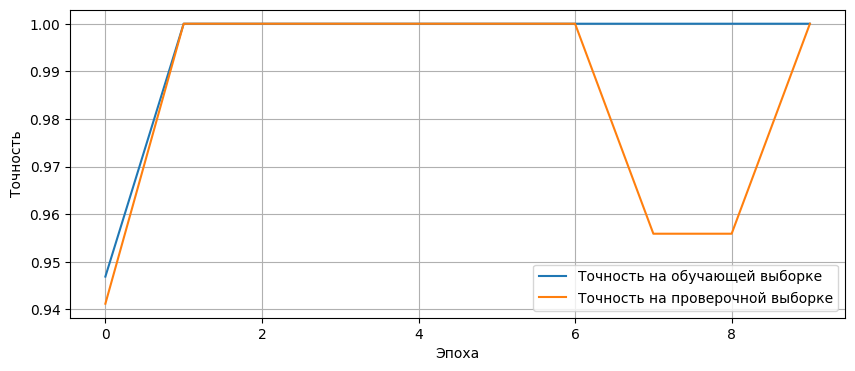

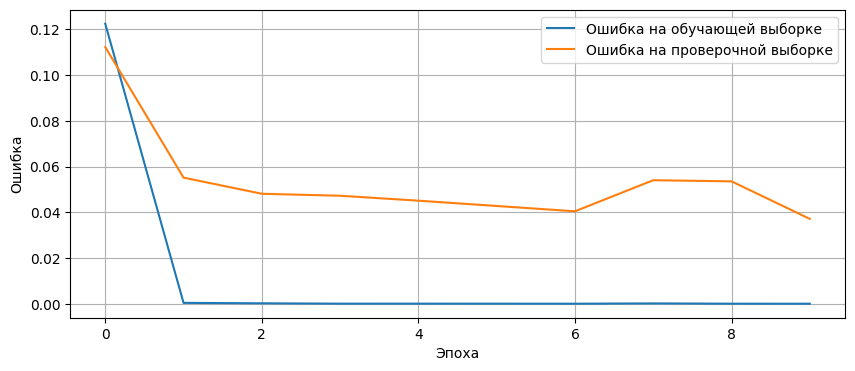

In [50]:
# создание модели
model = Sequential()

model.add(Dense(128, input_dim=vocab_size, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

# компиляция модели
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# обучение
history = model.fit(x_train, y_train, epochs=10, batch_size=8, validation_data=(x_test, y_test), verbose=1)

# оценка
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print('Ошибка на проверочной выборке:', test_loss)
print('Точность на проверочной выборке:', test_accuracy)

# графики обучения и ошибки
plt.figure(figsize=(10, 4))

plt.plot(history.history['accuracy'], label='Точность на обучающей выборке')
plt.plot(history.history['val_accuracy'], label='Точность на проверочной выборке')

plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 4))

plt.plot(history.history['loss'], label='Ошибка на обучающей выборке')
plt.plot(history.history['val_loss'], label='Ошибка на проверочной выборке')

plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.legend()
plt.grid()
plt.show()